In [ ]:
# CELL 1 — IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOP_WORDS = set(stopwords.words('english'))

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from scipy.stats import skew, kurtosis, zscore
from statsmodels.stats.weightstats import ztest

print('All imports successful')

All imports successful


In [ ]:
# CELL 2 — LOAD DATASET
df = pd.read_csv('/content/your_dataset_5000.csv')

print(df.shape)
print("Missing Values in: ",df.isnull().sum())
print("\nTotal missing values: ",df.isnull().sum().sum())
print("\nTotal Duplicate alues in dataset: ",df.duplicated().sum())

df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print("\nAfter Cleaning")
print('Dataset Shape:', df.shape)
print('\nLabel Distribution:')
print(df['label'].value_counts())
print('\nFirst 100 rows:')
df.head(100)

(5000, 2)
Missing Values in:  text     250
label    250
dtype: int64

Total missing values:  500

Total Duplicate alues in dataset:  4565

After Cleaning
Dataset Shape: (434, 2)

Label Distribution:
label
0.0    219
1.0    215
Name: count, dtype: int64

First 100 rows:


,text,label
0,Exercise plays a crucial role in supporting me...,1.0
1,Renewable energy helps fight climate change by...,1.0
2,"A futuristic smart city is a vibrant, intercon...",1.0
3,Healthy eating habits are especially important...,1.0
4,Machine learning is transforming healthcare by...,1.0
...,...,...
95,LiDAR sensors provide precise three-dimensiona...,1.0
96,Chatbots integrated into educational apps offe...,1.0
97,"Pilates strengthens the core muscles, improves...",1.0
98,Urban data platforms aggregate information fro...,1.0


In [ ]:
# CELL 3 — TEXT CLEANING
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
print('Text cleaning done')

Text cleaning done


In [ ]:
# CELL 4 — FEATURE ENGINEERING (14 FEATURES)

# Feature 1: Total character count
df['text_length'] = df['text'].apply(len)

# Feature 2: Total word count
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

# Feature 3: Average word length
df['avg_word_length'] = df['clean_text'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
)

# Feature 4: Unique word ratio (vocabulary diversity)
df['unique_word_ratio'] = df['clean_text'].apply(
    lambda x: len(set(x.split())) / len(x.split()) if x.split() else 0
)

# Feature 5: Sentence count
df['sentence_count'] = df['text'].apply(
    lambda x: max(1, len(re.split(r'[.!?]+', x.strip())))
)

# Feature 6: Average sentence length (words per sentence)
df['avg_sentence_length'] = df['word_count'] / df['sentence_count']

# Feature 7: Stopword ratio
df['stopword_ratio'] = df['clean_text'].apply(
    lambda x: len([w for w in x.split() if w in STOP_WORDS]) / len(x.split())
    if x.split() else 0
)

# Feature 8: Capital letter ratio
df['capital_ratio'] = df['text'].apply(
    lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0
)

# Feature 9: Punctuation count
df['punctuation_count'] = df['text'].apply(
    lambda x: sum(1 for c in x if c in string.punctuation)
)

# Feature 10: Exclamation mark count
df['exclamation_count'] = df['text'].apply(lambda x: x.count('!'))

# Feature 11: Question mark count
df['question_count'] = df['text'].apply(lambda x: x.count('?'))

# Feature 12: Digit count
df['digit_count'] = df['text'].apply(lambda x: sum(c.isdigit() for c in x))

# Feature 13: Long word count (words > 6 chars)
df['long_word_count'] = df['clean_text'].apply(
    lambda x: sum(1 for w in x.split() if len(w) > 6)
)

# Feature 14: Long word ratio
df['long_word_ratio'] = df['clean_text'].apply(
    lambda x: sum(1 for w in x.split() if len(w) > 6) / len(x.split())
    if x.split() else 0
)

FEATURES = [
    'text_length', 'word_count', 'avg_word_length', 'unique_word_ratio',
    'sentence_count', 'avg_sentence_length', 'stopword_ratio', 'capital_ratio',
    'punctuation_count', 'exclamation_count', 'question_count',
    'digit_count', 'long_word_count', 'long_word_ratio'
]

print(f'Feature Engineering Complete — {len(FEATURES)} features created')
print('\nFeature List:')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:2d}. {f}')
print('\nFeature Statistics:')
df[FEATURES].describe().round(4)

Feature Engineering Complete — 14 features created

Feature List:
   1. text_length
   2. word_count
   3. avg_word_length
   4. unique_word_ratio
   5. sentence_count
   6. avg_sentence_length
   7. stopword_ratio
   8. capital_ratio
   9. punctuation_count
  10. exclamation_count
  11. question_count
  12. digit_count
  13. long_word_count
  14. long_word_ratio

Feature Statistics:


,text_length,word_count,avg_word_length,unique_word_ratio,sentence_count,avg_sentence_length,stopword_ratio,capital_ratio,punctuation_count,exclamation_count,question_count,digit_count,long_word_count,long_word_ratio
count,434.0000,434.0000,434.0000,434.0000,434.0000,434.0000,434.0000,434.0000,434.0000,434.0000,434.0,434.0000,434.0000,434.0000
mean,104.1912,15.4309,5.7466,0.9733,2.1382,6.4900,0.2923,0.0184,2.0161,0.0046,0.0,0.0115,5.9424,0.3964
std,123.1851,17.8883,1.2712,0.0542,0.7685,2.5288,0.1394,0.0099,3.0207,0.0678,0.0,0.1266,7.2630,0.2008
min,40.0000,5.0000,3.2500,0.6957,2.0000,2.5000,0.0000,0.0058,1.0000,0.0000,0.0,0.0000,0.0000,0.0000
25%,63.2500,11.0000,4.7000,0.9643,2.0000,5.5000,0.1778,0.0103,1.0000,0.0000,0.0,0.0000,3.0000,0.2386
50%,77.0000,13.0000,5.7247,1.0000,2.0000,6.5000,0.2857,0.0156,1.0000,0.0000,0.0,0.0000,4.0000,0.3846
75%,103.0000,14.0000,6.7644,1.0000,2.0000,7.0000,0.4000,0.0235,2.0000,0.0000,0.0,0.0000,7.0000,0.5437
max,853.0000,125.0000,10.1111,1.0000,7.0000,21.0000,0.6429,0.0600,25.0000,1.0000,0.0,2.0000,58.0000,1.0000


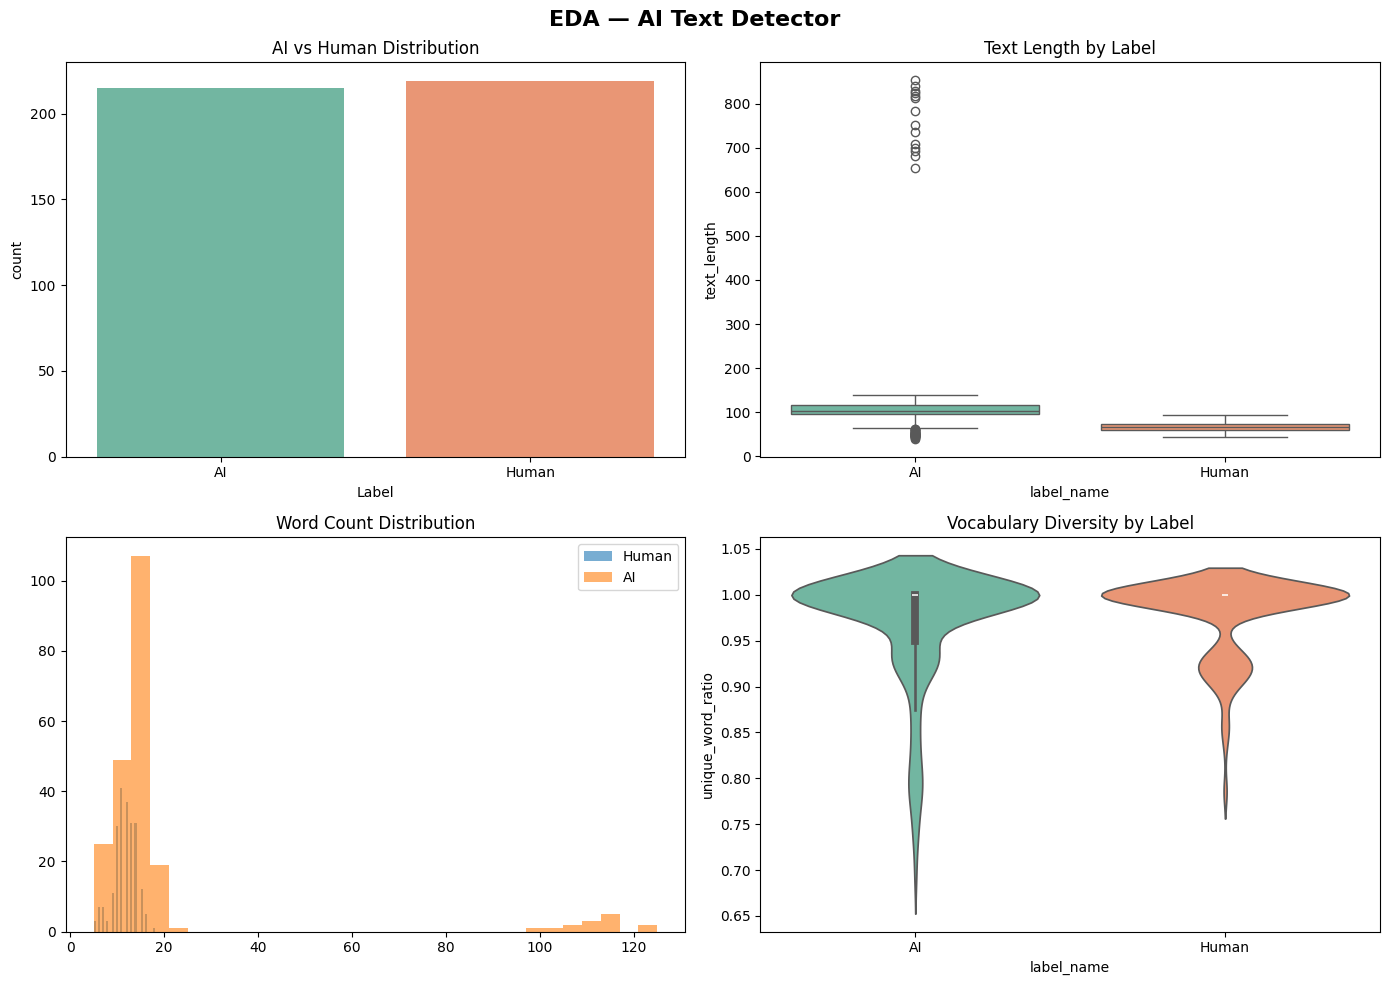

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA — AI Text Detector', fontsize=16, fontweight='bold')

label_map = {0: 'Human', 1: 'AI'}
df['label_name'] = df['label'].map(label_map)
sns.countplot(x='label_name', data=df, palette='Set2', ax=axes[0,0])
axes[0,0].set_title('AI vs Human Distribution')
axes[0,0].set_xlabel('Label')

sns.boxplot(x='label_name', y='text_length', data=df, palette='Set2', ax=axes[0,1])
axes[0,1].set_title('Text Length by Label')

for label in [0, 1]:
    subset = df[df['label']==label]['word_count']
    axes[1,0].hist(subset, bins=30, alpha=0.6, label=label_map[label])
axes[1,0].set_title('Word Count Distribution')
axes[1,0].legend()

sns.violinplot(x='label_name', y='unique_word_ratio', data=df, palette='Set2', ax=axes[1,1])
axes[1,1].set_title('Vocabulary Diversity by Label')

plt.tight_layout()
plt.show()

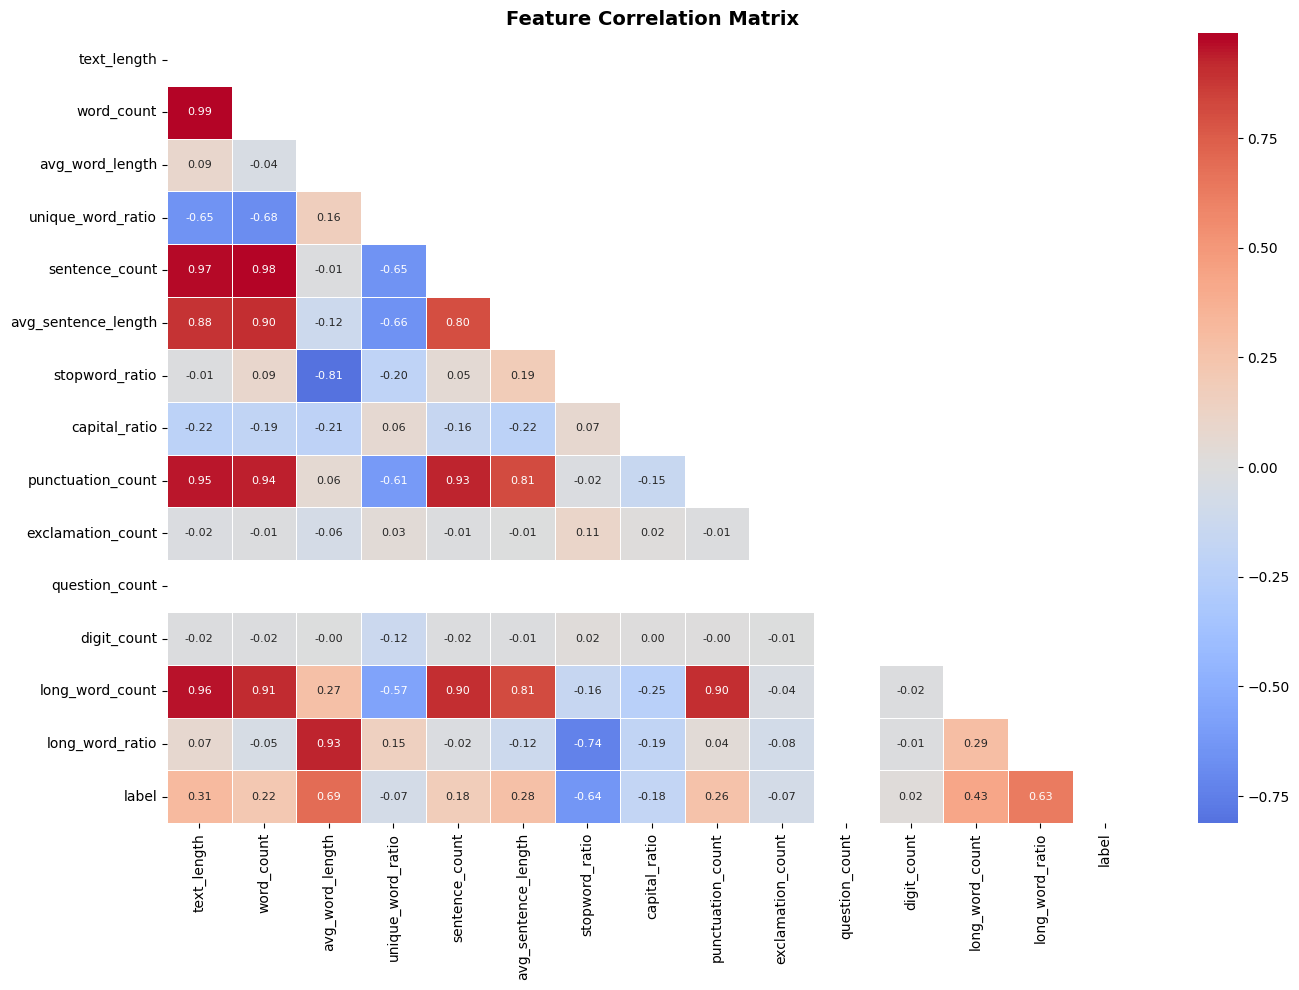


Top Features Correlated with Label:
avg_word_length        0.6915
stopword_ratio        -0.6350
long_word_ratio        0.6266
long_word_count        0.4265
text_length            0.3083
avg_sentence_length    0.2770
punctuation_count      0.2589
word_count             0.2167
capital_ratio         -0.1842
sentence_count         0.1818
unique_word_ratio     -0.0719
exclamation_count     -0.0674
digit_count            0.0191
question_count            NaN
Name: label, dtype: float64


In [ ]:
# CELL 6 — FEATURE CORRELATION HEATMAP
plt.figure(figsize=(14, 10))
corr = df[FEATURES + ['label']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop Features Correlated with Label:')
label_corr = corr['label'].drop('label').sort_values(key=abs, ascending=False)
print(label_corr.round(4))

In [ ]:
# CELL 7 — SKEWNESS & KURTOSIS (ALL 14 FEATURES) — SYMMETRY CHECK
print('=' * 65)
print('  STATISTICAL ANALYSIS — SYMMETRY CHECK (ALL 14 FEATURES)')
print('=' * 65)

sym_results = []

for feat in FEATURES:
    data = df[feat]
    sk   = skew(data)
    kurt = kurtosis(data)

    if abs(sk) < 0.5:
        sym_label = 'Approximately Symmetric'
    elif sk > 0.5:
        sym_label = 'Right-Skewed (positive tail)'
    else:
        sym_label = 'Left-Skewed (negative tail)'

    if abs(kurt) < 1:
        kurt_label = 'Mesokurtic (normal-like)'
    elif kurt > 1:
        kurt_label = 'Leptokurtic (heavy tails)'
    else:
        kurt_label = 'Platykurtic (flat tails)'

    sym_results.append({
        'Feature': feat, 'Mean': round(data.mean(), 3),
        'Std': round(data.std(), 3), 'Skewness': round(sk, 4),
        'Kurtosis': round(kurt, 4), 'Symmetry': sym_label
    })

sym_df = pd.DataFrame(sym_results)
print('\n\nSummary Table:')
sym_df[['Feature', 'Skewness', 'Kurtosis', 'Symmetry']]

  STATISTICAL ANALYSIS — SYMMETRY CHECK (ALL 14 FEATURES)


Summary Table:


,Feature,Skewness,Kurtosis,Symmetry
0,char_count,5.0730,25.0536,Right-Skewed (positive tail)
1,word_count,5.1303,25.2359,Right-Skewed (positive tail)
2,avg_word_length,0.1980,-0.6312,Approximately Symmetric
3,unique_word_ratio,-2.3505,5.6190,Left-Skewed (negative tail)
4,sentence_count,5.5066,28.9988,Right-Skewed (positive tail)
5,avg_sentence_length,2.9695,12.5632,Right-Skewed (positive tail)
6,stopword_ratio,0.0118,-0.6720,Approximately Symmetric
7,capital_ratio,1.3496,1.7602,Right-Skewed (positive tail)
8,punctuation_count,5.2293,29.0216,Right-Skewed (positive tail)
9,exclamation_count,14.6289,212.0046,Right-Skewed (positive tail)


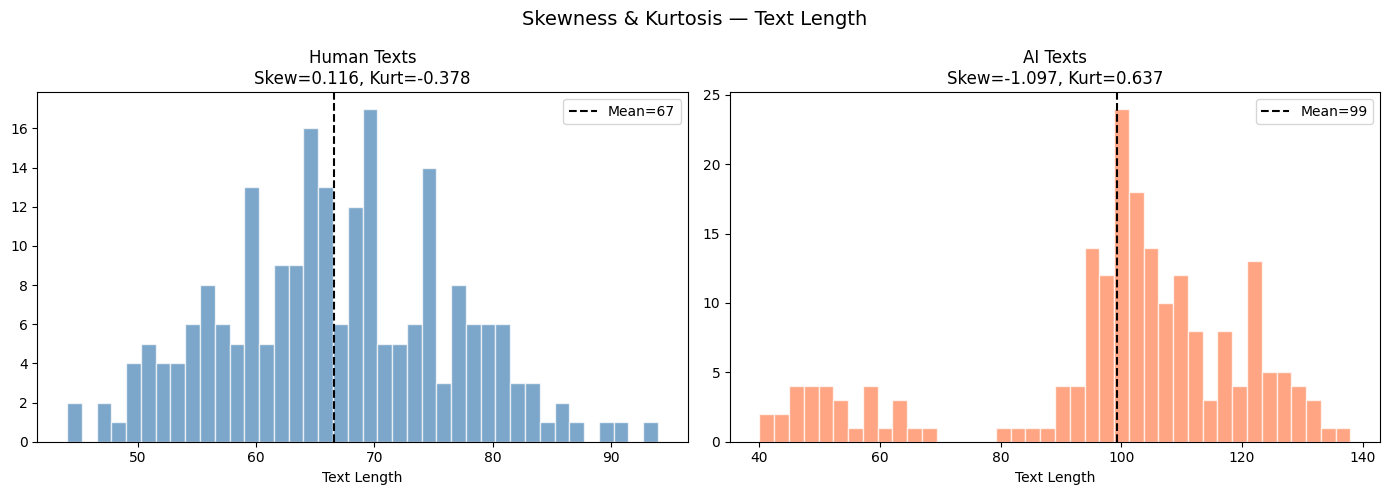

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Skewness & Kurtosis — Text Length', fontsize=14)

for ax, label, color in zip(axes, [0, 1], ['steelblue', 'coral']):
    data = df_clean[df_clean['label']==label]['char_count']
    ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(data.mean(), color='black', linestyle='--', label=f'Mean={data.mean():.0f}')
    ax.set_title(f'{label_map[label]} Texts\nSkew={skew(data):.3f}, Kurt={kurtosis(data):.3f}')
    ax.legend()
    ax.set_xlabel('Text Length')

plt.tight_layout()
plt.show()

In [ ]:
# CELL 9 — Z-SCORE OUTLIER DETECTION
print('=' * 65)
print('  Z-SCORE OUTLIER DETECTION  (|z| > 3 = outlier)')
print('=' * 65)

for feat in FEATURES:
    z_scores = np.abs(zscore(df[feat]))
    outliers = (z_scores > 3).sum()
    pct = outliers / len(df) * 100
    print(f'{feat:30s}: {outliers:4d} outliers ({pct:.2f}%)')

z = np.abs(zscore(df['text_length']))
df_clean = df[z < 3].copy()
print(f'\nDataset after outlier removal: {df_clean.shape[0]} rows')
print(f'Rows removed: {len(df) - len(df_clean)}')

  Z-SCORE OUTLIER DETECTION  (|z| > 3 = outlier)
text_length                   :   14 outliers (3.23%)
word_count                    :   14 outliers (3.23%)
avg_word_length               :    1 outliers (0.23%)
unique_word_ratio             :   15 outliers (3.46%)
sentence_count                :   14 outliers (3.23%)
avg_sentence_length           :   14 outliers (3.23%)
stopword_ratio                :    0 outliers (0.00%)
capital_ratio                 :    6 outliers (1.38%)
punctuation_count             :   13 outliers (3.00%)
exclamation_count             :    2 outliers (0.46%)
question_count                :    0 outliers (0.00%)
digit_count                   :    4 outliers (0.92%)
long_word_count               :   12 outliers (2.76%)
long_word_ratio               :    2 outliers (0.46%)

Dataset after outlier removal: 420 rows
Rows removed: 14


In [ ]:
# CELL 10 — TWO-SAMPLE Z-TEST (AI vs HUMAN)
print('=' * 65)
print('  TWO-SAMPLE Z-TEST: AI vs Human (Key Features)')
print('=' * 65)

test_features = ['text_length', 'word_count', 'unique_word_ratio',
                 'avg_sentence_length', 'long_word_ratio', 'stopword_ratio']

for feat in test_features:
    ai_vals    = df_clean[df_clean['label'] == 1][feat]
    human_vals = df_clean[df_clean['label'] == 0][feat]
    z_stat, p_value = ztest(ai_vals, human_vals, alternative='two-sided')
    result = 'Significant (p < 0.05)' if p_value < 0.05 else 'Not Significant (p >= 0.05)'
    print(f'\n{feat}')
    print(f'   AI Mean    : {ai_vals.mean():.4f}')
    print(f'   Human Mean : {human_vals.mean():.4f}')
    print(f'   Z-Statistic: {z_stat:.4f}  |  P-Value: {p_value:.6f}')
    print(f'   Result     : {result}')

  TWO-SAMPLE Z-TEST: AI vs Human (Key Features)

text_length
   AI Mean    : 99.2537
   Human Mean : 66.6073
   Z-Statistic: 19.6516  |  P-Value: 0.000000
   Result     : Significant (p < 0.05)

word_count
   AI Mean    : 12.8955
   Human Mean : 11.5936
   Z-Statistic: 4.8341  |  P-Value: 0.000001
   Result     : Significant (p < 0.05)

unique_word_ratio
   AI Mean    : 0.9827
   Human Mean : 0.9771
   Z-Statistic: 1.4101  |  P-Value: 0.158523
   Result     : Not Significant (p >= 0.05)

avg_sentence_length
   AI Mean    : 6.4478
   Human Mean : 5.7968
   Z-Statistic: 4.8341  |  P-Value: 0.000001
   Result     : Significant (p < 0.05)

long_word_ratio
   AI Mean    : 0.5334
   Human Mean : 0.2719
   Z-Statistic: 17.1587  |  P-Value: 0.000000
   Result     : Significant (p < 0.05)

stopword_ratio
   AI Mean    : 0.1940
   Human Mean : 0.3798
   Z-Statistic: -17.8528  |  P-Value: 0.000000
   Result     : Significant (p < 0.05)


In [ ]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = vectorizer.fit_transform(df_clean['clean_text'])
y = df_clean['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000),
    'Naive Bayes'         : MultinomialNB(),
    'Linear SVM'          : LinearSVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred  = model.predict(X_test)
    acc   = accuracy_score(y_test, pred)
    cv    = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    results[name] = {'accuracy': acc, 'cv_mean': cv.mean(), 'cv_std': cv.std()}
    print(f'--- {name} ---')
    print(f'  Test Accuracy : {acc:.4f}')
    print(f'  CV (5-fold)   : {cv.mean():.4f} ± {cv.std():.4f}')
    print(classification_report(y_test, pred, target_names=['Human','AI']))

--- Logistic Regression ---
  Test Accuracy : 0.9405
  CV (5-fold)   : 0.9405 ± 0.0955
              precision    recall  f1-score   support

       Human       0.95      0.93      0.94        44
          AI       0.93      0.95      0.94        40

    accuracy                           0.94        84
   macro avg       0.94      0.94      0.94        84
weighted avg       0.94      0.94      0.94        84

--- Naive Bayes ---
  Test Accuracy : 0.9762
  CV (5-fold)   : 0.9786 ± 0.0314
              precision    recall  f1-score   support

       Human       0.98      0.98      0.98        44
          AI       0.97      0.97      0.97        40

    accuracy                           0.98        84
   macro avg       0.98      0.98      0.98        84
weighted avg       0.98      0.98      0.98        84

--- Linear SVM ---
  Test Accuracy : 0.9524
  CV (5-fold)   : 0.9429 ± 0.1025
              precision    recall  f1-score   support

       Human       0.98      0.93      0.95    

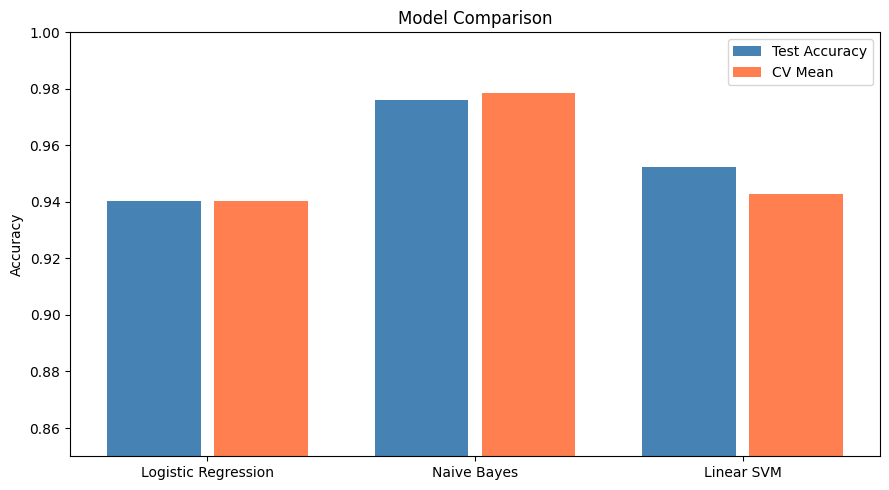

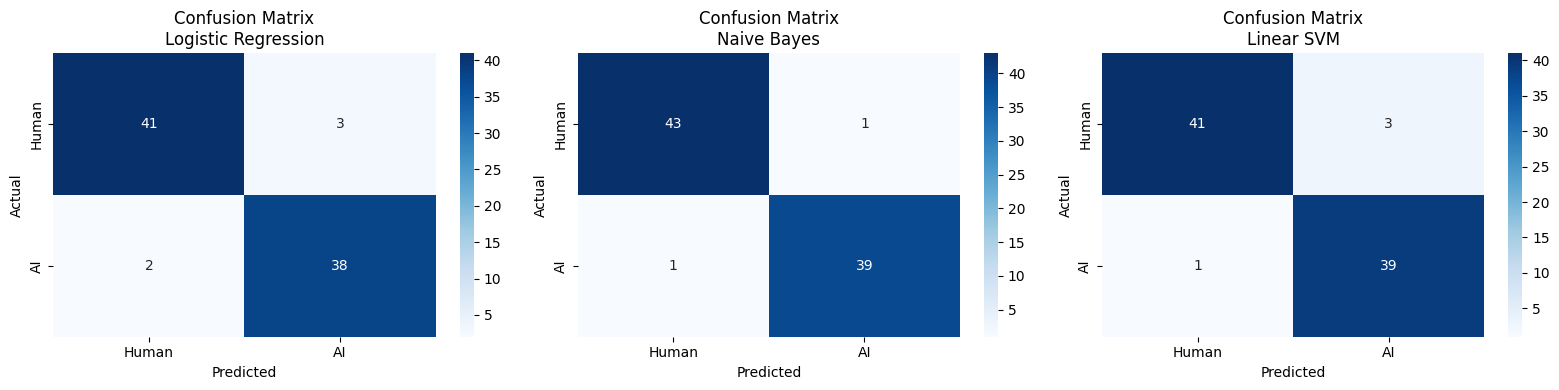

In [ ]:
names   = list(results.keys())
accs    = [results[n]['accuracy'] for n in names]
cv_means= [results[n]['cv_mean']  for n in names]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.2, accs,    0.35, label='Test Accuracy', color='steelblue')
ax.bar(x + 0.2, cv_means, 0.35, label='CV Mean',      color='coral')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, model) in zip(axes, models.items()):
    pred = model.predict(X_test)
    cm   = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Human','AI'], yticklabels=['Human','AI'])
    ax.set_title(f'Confusion Matrix\n{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


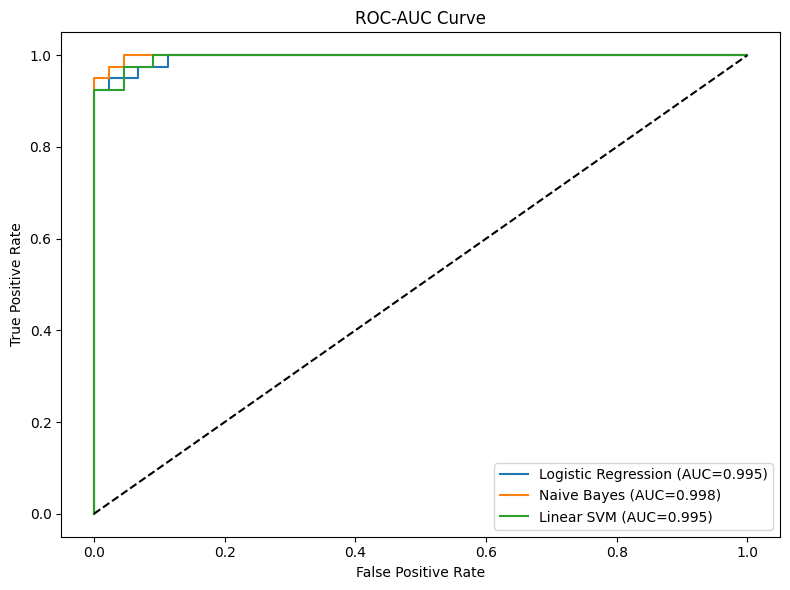

In [ ]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(X_test)[:, 1]
    else:
        scores = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend()
plt.tight_layout()
plt.show()

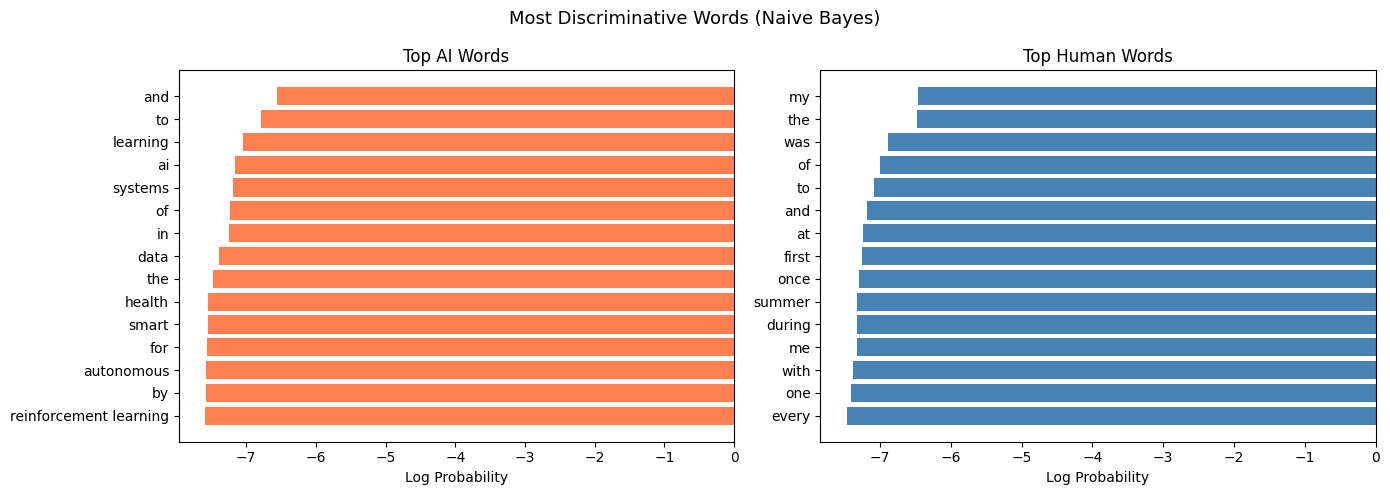

In [ ]:
nb_model = models['Naive Bayes']
feature_names = vectorizer.get_feature_names_out()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, class_idx, title, color in [
    (axes[0], 1, 'Top AI Words', 'coral'),
    (axes[1], 0, 'Top Human Words', 'steelblue')
]:
    top_idx   = np.argsort(nb_model.feature_log_prob_[class_idx])[-15:]
    top_words = [feature_names[i] for i in top_idx]
    top_vals  = nb_model.feature_log_prob_[class_idx][top_idx]
    ax.barh(top_words, top_vals, color=color)
    ax.set_title(title)
    ax.set_xlabel('Log Probability')

plt.suptitle('Most Discriminative Words (Naive Bayes)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
best_model = models['Logistic Regression']

def predict_text(text, model=best_model):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])

    prediction = model.predict(vec)[0]
    if hasattr(model, 'predict_proba'):
        confidence = max(model.predict_proba(vec)[0])
    else:
        confidence = None

    sentences = [s.strip() for s in text.split('.') if s.strip()]
    ai_count  = 0
    for sent in sentences:
        v = vectorizer.transform([clean_text(sent)])
        if model.predict(v)[0] == 1:
            ai_count += 1
    ai_pct = (ai_count / len(sentences) * 100) if sentences else 0

    label = 'AI Generated' if prediction == 1 else 'Human Written'
    print('===== RESULT =====')
    print(f'Label      : {label}')
    print(f'AI %       : {ai_pct:.1f}%')
    if confidence:
        print(f'Confidence : {confidence:.2%}')
    return prediction, ai_pct, confidence

user_text = input('Enter text to detect:\n')
predict_text(user_text)

Enter text to detect:
Heyy i am Rishabh Can you be my friend
===== RESULT =====
Label      : Human Written
AI %       : 0.0%
Confidence : 60.77%


(np.float64(0.0), 0.0, np.float64(0.6076741881174246))

In [ ]:
print('=' * 60)
print('  PROJECT SUMMARY — AI Text Detector')
print('=' * 60)
print(f'Dataset size    : {df_clean.shape[0]} samples (balanced)')
print(f'Features used   : TF-IDF (5000 features, unigrams+bigrams)')
print()
print('MODEL RESULTS:')
for name, r in results.items():
    print(f'  {name:25s}: Test={r["accuracy"]:.4f}, CV={r["cv_mean"]:.4f}±{r["cv_std"]:.4f}')
print()
print('STATISTICAL HIGHLIGHTS:')
print('  • Skewness & Kurtosis computed for all numerical features')
print('  • Z-Score based outlier removal applied')
print('  • Two-sample Z-Test confirms AI/Human text length difference')
print()

  PROJECT SUMMARY — AI Text Detector
Dataset size    : 420 samples (balanced)
Features used   : TF-IDF (5000 features, unigrams+bigrams)

MODEL RESULTS:
  Logistic Regression      : Test=0.9405, CV=0.9405±0.0955
  Naive Bayes              : Test=0.9762, CV=0.9786±0.0314
  Linear SVM               : Test=0.9524, CV=0.9429±0.1025

STATISTICAL HIGHLIGHTS:
  • Skewness & Kurtosis computed for all numerical features
  • Z-Score based outlier removal applied
  • Two-sample Z-Test confirms AI/Human text length difference

